# 🎨 Step 6 — Advanced Visualizations

**Protein Function Prediction Using Genomic Language Model (ESM-2)**

Publication-quality embedding visualizations using t-SNE, UMAP, similarity analysis, and a comprehensive dashboard.

---

### Output
| File | Description |
|------|-------------|
| `results/plots/tsne_embeddings.png` | t-SNE projection colored by GO term |
| `results/plots/umap_embeddings.png` | UMAP projection |
| `results/plots/go_similarity_heatmap.png` | Centroid cosine similarity |
| `results/plots/freq_vs_f1.png` | Frequency–F1 analysis |
| `results/plots/comprehensive_dashboard.png` | Multi-panel summary |

In [1]:
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from scipy.spatial.distance import cosine

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('⚠️  umap-learn not installed — UMAP plots will be skipped')

# ─── Configuration ───
PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
METRICS_DIR = os.path.join(PROJECT_ROOT, 'results', 'metrics')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'plots')
SEED = 42
np.random.seed(SEED)
plt.style.use('dark_background')
COLORS = ['#00D4FF', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A855F7',
          '#F97316', '#06B6D4', '#EC4899', '#84CC16', '#F43F5E']

print('✅ Imports ready')

✅ Imports ready


## 6.1 — Load Embeddings & Labels

In [2]:
emb_test = np.load(os.path.join(PROCESSED_DIR, 'embeddings_test.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'labels_test.npy'))
with open(os.path.join(PROCESSED_DIR, 'label_binarizer.pkl'), 'rb') as f:
    mlb = pickle.load(f)
go_terms = mlb.classes_

# Load evaluation report for F1 scores
eval_path = os.path.join(METRICS_DIR, 'evaluation_report.json')
if os.path.exists(eval_path):
    with open(eval_path) as f:
        eval_metrics = json.load(f)

# Also try per-class metrics
pc_path = os.path.join(METRICS_DIR, 'per_class_metrics.csv')
if os.path.exists(pc_path):
    pc_df = pd.read_csv(pc_path)

# Assign dominant label (highest-weighted GO term) per sample for coloring
dominant_label = y_test.argmax(axis=1)

print(f'📊 Test embeddings: {emb_test.shape}')
print(f'🏷️  GO classes: {len(go_terms)}')

📊 Test embeddings: (197, 320)
🏷️  GO classes: 50


## 6.2 — t-SNE Projection

🔄 Computing t-SNE...


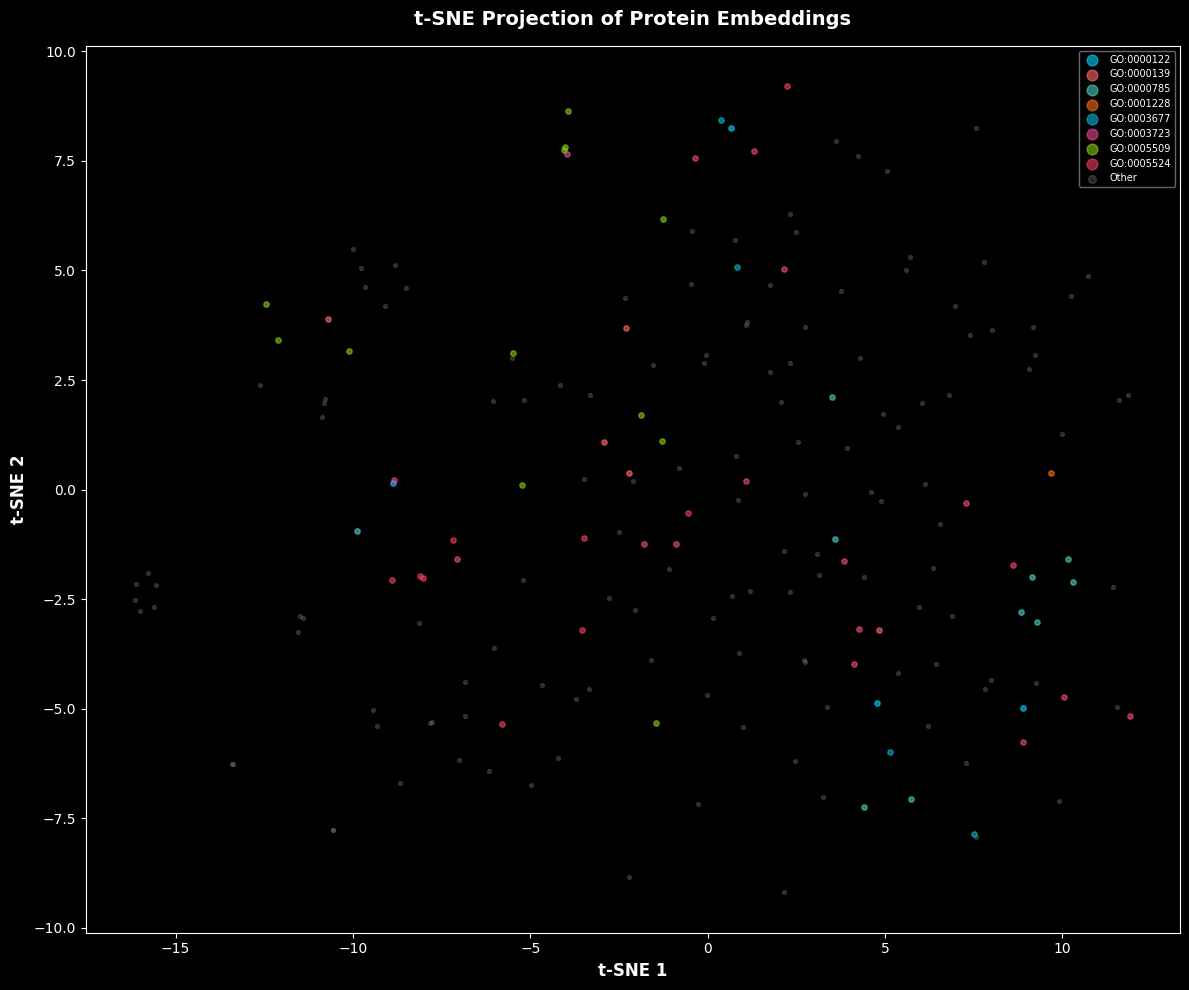

In [3]:
print('🔄 Computing t-SNE...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(emb_test)-1), max_iter=1000)
tsne_2d = tsne.fit_transform(emb_test)

fig, ax = plt.subplots(figsize=(12, 10))
n_colors = min(10, len(go_terms))
for i in range(n_colors):
    mask = dominant_label == i
    if mask.sum() > 0:
        ax.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], c=COLORS[i % len(COLORS)],
                   s=15, alpha=0.6, label=go_terms[i][:20])
# Others
other_mask = dominant_label >= n_colors
if other_mask.sum() > 0:
    ax.scatter(tsne_2d[other_mask, 0], tsne_2d[other_mask, 1], c='gray',
               s=8, alpha=0.3, label='Other')

ax.set_xlabel('t-SNE 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE 2', fontsize=12, fontweight='bold')
ax.set_title('t-SNE Projection of Protein Embeddings', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=7, loc='best', markerscale=2, framealpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'tsne_embeddings.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6.3 — UMAP Projection

🔄 Computing UMAP...


C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


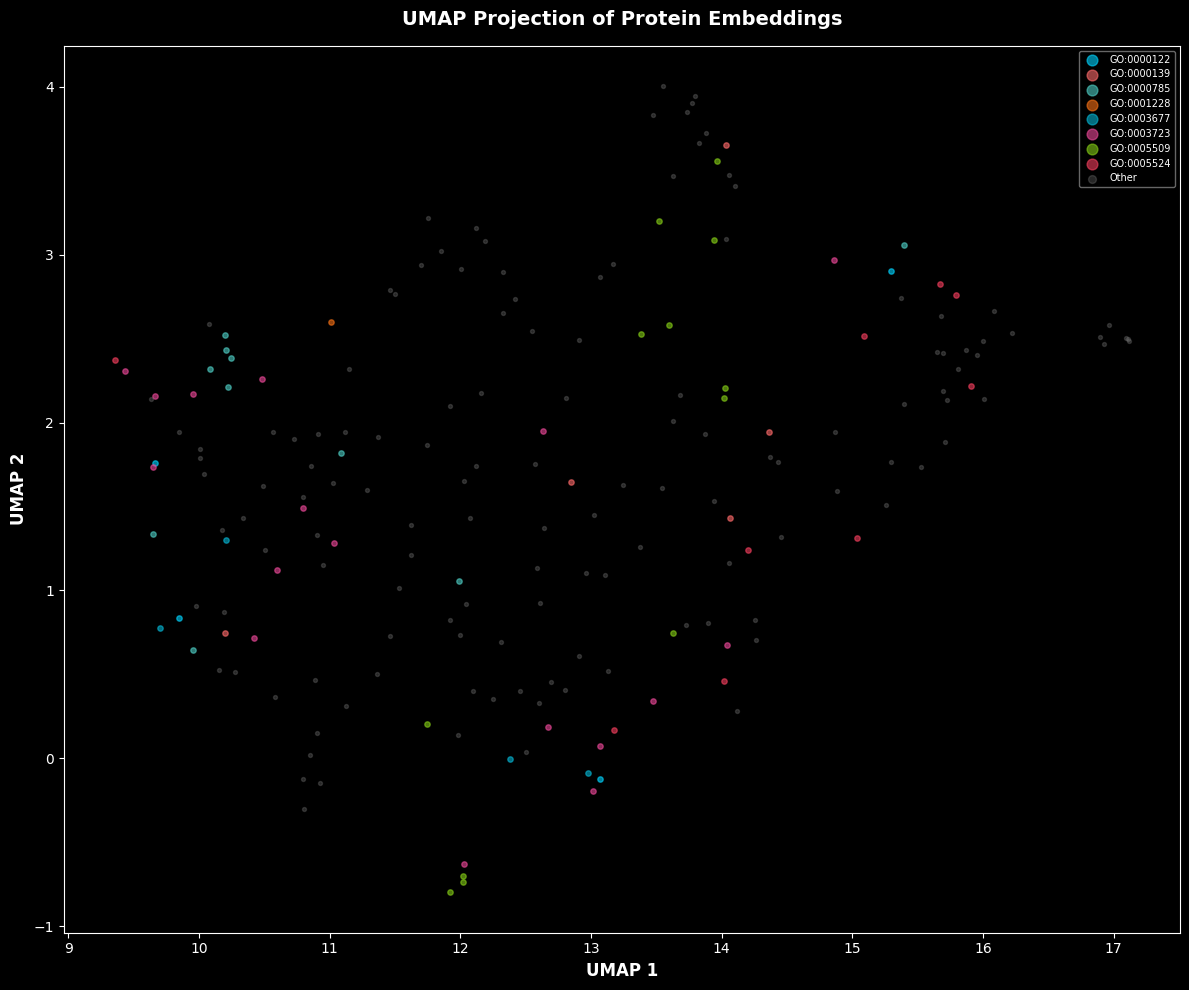

In [4]:
if HAS_UMAP:
    print('🔄 Computing UMAP...')
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    umap_2d = reducer.fit_transform(emb_test)

    fig, ax = plt.subplots(figsize=(12, 10))
    for i in range(n_colors):
        mask = dominant_label == i
        if mask.sum() > 0:
            ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1], c=COLORS[i % len(COLORS)],
                       s=15, alpha=0.6, label=go_terms[i][:20])
    other_mask = dominant_label >= n_colors
    if other_mask.sum() > 0:
        ax.scatter(umap_2d[other_mask, 0], umap_2d[other_mask, 1], c='gray',
                   s=8, alpha=0.3, label='Other')

    ax.set_xlabel('UMAP 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('UMAP 2', fontsize=12, fontweight='bold')
    ax.set_title('UMAP Projection of Protein Embeddings', fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=7, loc='best', markerscale=2, framealpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'umap_embeddings.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('⏭️  UMAP skipped (install umap-learn)')

## 6.4 — GO Term Centroid Similarity

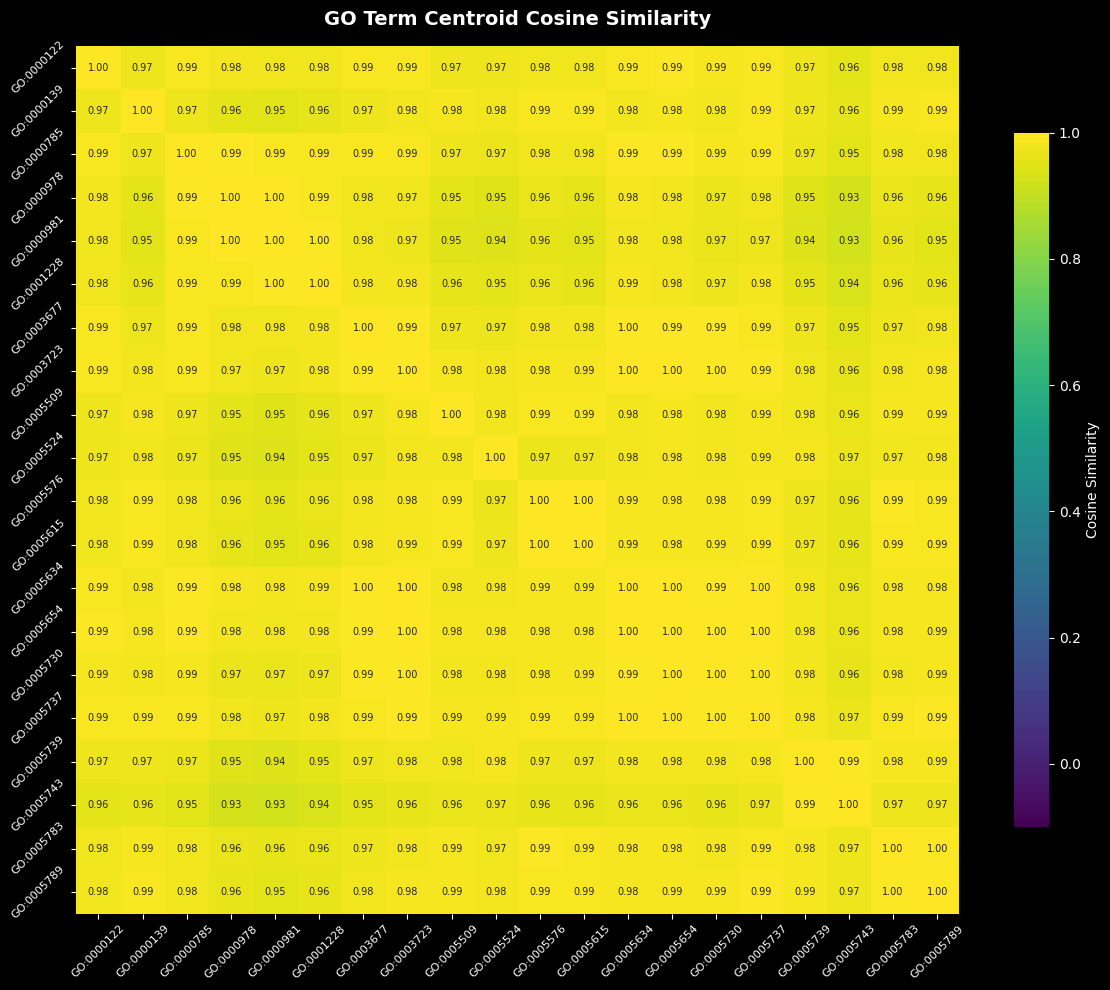

In [5]:
# Compute centroids for each GO term
n_show = min(20, len(go_terms))
centroids = []
valid_terms = []
for i in range(n_show):
    mask = y_test[:, i] == 1
    if mask.sum() > 0:
        centroids.append(emb_test[mask].mean(axis=0))
        valid_terms.append(go_terms[i])
centroids = np.array(centroids)

# Cosine similarity matrix
n = len(centroids)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = 1 - cosine(centroids[i], centroids[j])

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_matrix, ax=ax, cmap='viridis', vmin=-0.1, vmax=1.0,
            xticklabels=valid_terms, yticklabels=valid_terms,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'})
ax.set_title('GO Term Centroid Cosine Similarity', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(labelsize=8, labelrotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'go_similarity_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6.5 — Frequency vs F1 Score Analysis

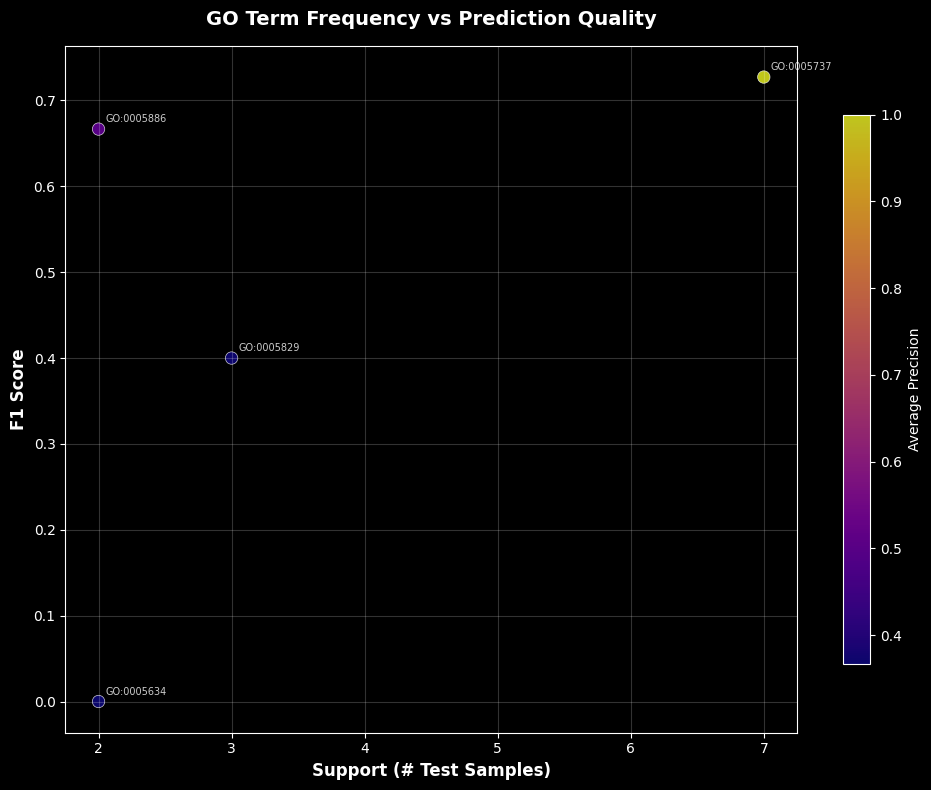

In [6]:
if os.path.exists(pc_path):
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        pc_df['support'], pc_df['f1_score'],
        c=pc_df['avg_precision'], cmap='plasma', s=80, alpha=0.8, edgecolors='white', lw=0.5
    )
    plt.colorbar(scatter, ax=ax, label='Average Precision', shrink=0.8)
    ax.set_xlabel('Support (# Test Samples)', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    ax.set_title('GO Term Frequency vs Prediction Quality', fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.2)

    # Annotate outliers
    for _, row in pc_df.nlargest(5, 'f1_score').iterrows():
        ax.annotate(row['go_term'][:15], (row['support'], row['f1_score']),
                    fontsize=7, alpha=0.8, color='white',
                    xytext=(5, 5), textcoords='offset points')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'freq_vs_f1.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('⏭️  Run 04_evaluate_and_results.ipynb first')

## 6.6 — 📊 Comprehensive Dashboard

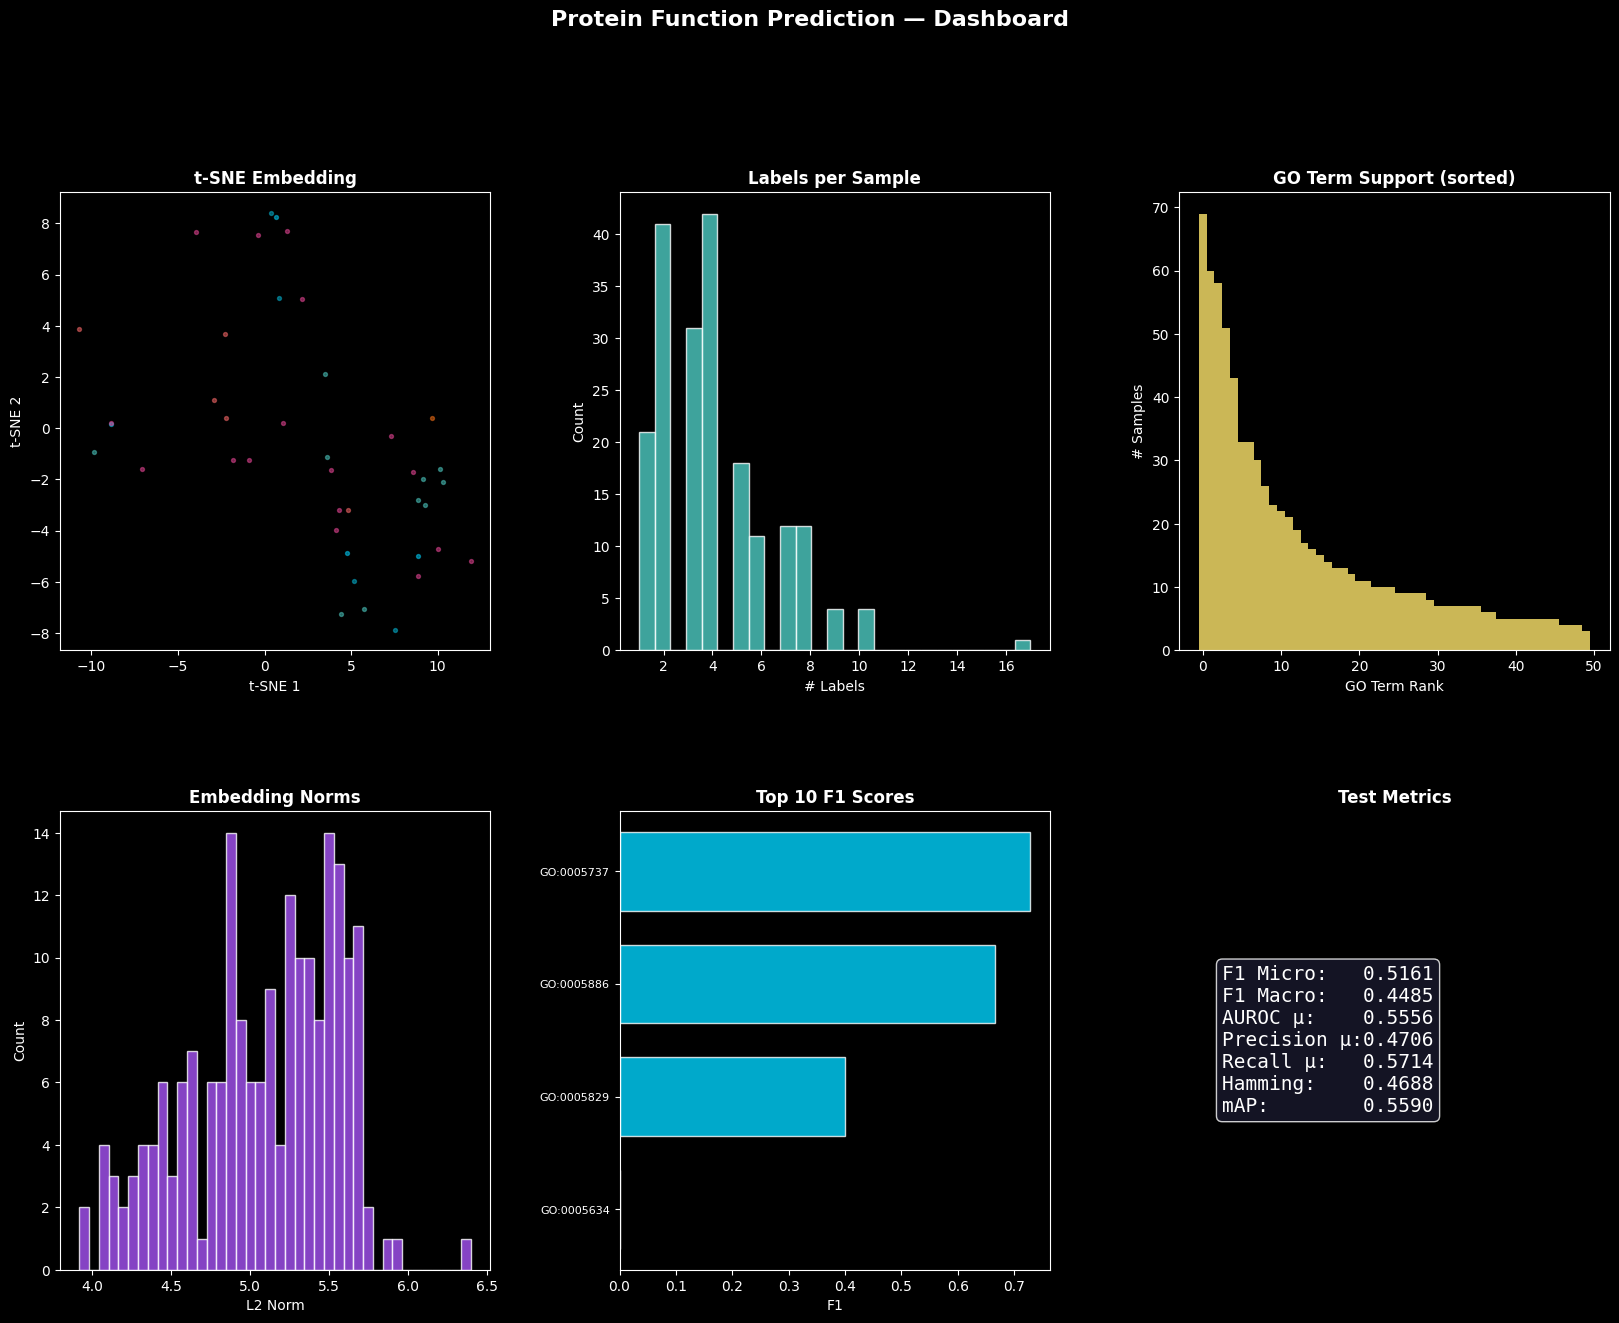

✅ Dashboard saved!


In [7]:
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# 1. t-SNE
ax = fig.add_subplot(gs[0, 0])
for i in range(min(8, len(go_terms))):
    mask = dominant_label == i
    if mask.sum() > 0:
        ax.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], c=COLORS[i], s=8, alpha=0.5)
ax.set_title('t-SNE Embedding', fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

# 2. Label distribution
ax = fig.add_subplot(gs[0, 1])
lps = y_test.sum(axis=1)
ax.hist(lps, bins=25, color=COLORS[2], alpha=0.8, edgecolor='white')
ax.set_title('Labels per Sample', fontsize=12, fontweight='bold')
ax.set_xlabel('# Labels'); ax.set_ylabel('Count')

# 3. Per-class support
ax = fig.add_subplot(gs[0, 2])
support = y_test.sum(axis=0)
ax.bar(range(len(support)), sorted(support, reverse=True), color=COLORS[3], alpha=0.8, width=1)
ax.set_title('GO Term Support (sorted)', fontsize=12, fontweight='bold')
ax.set_xlabel('GO Term Rank'); ax.set_ylabel('# Samples')

# 4. Embedding norm
ax = fig.add_subplot(gs[1, 0])
norms = np.linalg.norm(emb_test, axis=1)
ax.hist(norms, bins=40, color=COLORS[4], alpha=0.8, edgecolor='white')
ax.set_title('Embedding Norms', fontsize=12, fontweight='bold')
ax.set_xlabel('L2 Norm'); ax.set_ylabel('Count')

# 5. Top per-class F1 (if available)
ax = fig.add_subplot(gs[1, 1])
if os.path.exists(pc_path):
    top10 = pc_df.nlargest(10, 'f1_score')
    ax.barh(range(len(top10)), top10['f1_score'].values,
            color=COLORS[0], alpha=0.8, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10['go_term'].values, fontsize=8)
    ax.invert_yaxis()
ax.set_title('Top 10 F1 Scores', fontsize=12, fontweight='bold')
ax.set_xlabel('F1')

# 6. Metrics summary
ax = fig.add_subplot(gs[1, 2])
ax.axis('off')
if os.path.exists(eval_path):
    text = '\n'.join([
        f'F1 Micro:   {eval_metrics.get("f1_micro", 0):.4f}',
        f'F1 Macro:   {eval_metrics.get("f1_macro", 0):.4f}',
        f'AUROC µ:    {eval_metrics.get("auroc_micro", 0):.4f}',
        f'Precision µ:{eval_metrics.get("precision_micro", 0):.4f}',
        f'Recall µ:   {eval_metrics.get("recall_micro", 0):.4f}',
        f'Hamming:    {eval_metrics.get("hamming_loss", 0):.4f}',
        f'mAP:        {eval_metrics.get("mean_average_precision", 0):.4f}',
    ])
    ax.text(0.1, 0.5, text, fontsize=14, fontfamily='monospace',
            verticalalignment='center', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8))
ax.set_title('Test Metrics', fontsize=12, fontweight='bold')

fig.suptitle('Protein Function Prediction — Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.savefig(os.path.join(PLOTS_DIR, 'comprehensive_dashboard.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved!')

---
### ✅ All Visualizations Complete!